# **Konturlar**

####**Bu derste şunları öğreneceğiz:**
1. findContours'u kullanma
2. Kontur Çizimi
3. Konturların Hiyerarşisi
4. Konturlama Modları (Basit vs Yaklaşık)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Kontur Nedir?**
Konturlar, bir nesnenin tüm sınırını sınırlayan veya kapsayan sürekli çizgiler veya eğrilerdir.

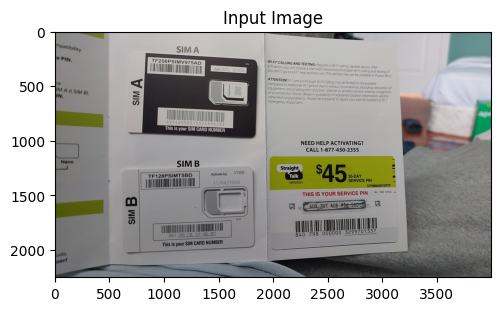

In [2]:
# Basit bir plaka görüntüsü yükleyelim
image = cv2.imread('../files/images/america12.jpg')
imshow('Input Image', image)

#### **Cv2.findContours()** işlevinin uygulanması

```cv2.findContours(image, Retrieval Mode, Approximation Method)``

**Kontur bulma modu**
- **RETR_LIST** - Tüm konturları alır, ancak herhangi bir ebeveyn-çocuk ilişkisi oluşturmaz. Ebeveynler ve çocuklar bu kural altında eşittir ve sadece konturlardır. yani hepsi aynı hiyerarşi seviyesine aittir.
- **RETR_EXTERNAL** - sadece aşırı dış bayrakları döndürür. Tüm alt konturlar geride bırakılır.
- **RETR_CCOMP** - Bu bayrak tüm konturları alır ve bunları 2 seviyeli bir hiyerarşiye göre düzenler. yani nesnenin dış konturları (yani sınırları) hiyerarşi-1'e yerleştirilir. Ve nesnenin içindeki deliklerin konturları (varsa) hiyerarşi-2'ye yerleştirilir. İçinde herhangi bir nesne varsa, konturu yine sadece hiyerarşi-1'e yerleştirilir. Ve deliği hiyerarşi-2'de vb.
- **RETR_TREE** - Tüm konturları alır ve tam bir aile hiyerarşisi listesi oluşturur.

**Yaklaşım Yöntemi Seçenekleri**
- cv2.CHAIN_APPROX_NONE - Çizgi boyunca tüm noktaları depolar (verimsiz!)
- cv2.CHAIN_APPROX_SIMPLE - Her çizginin bitiş noktalarını saklar

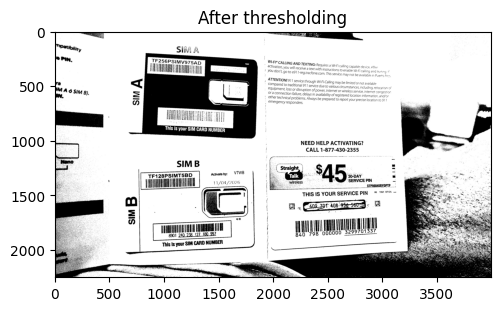

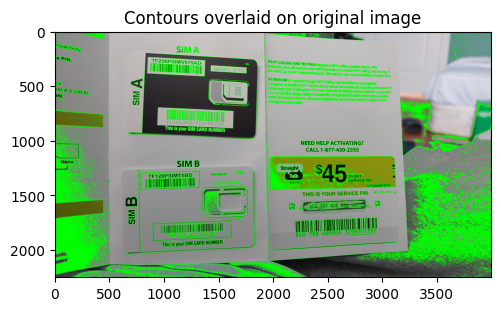

Number of Contours found = 48169


In [3]:
image = cv2.imread('../files/images/america12.jpg')

# Gri Tonlamaya Dönüştür
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Konturları Bulma
#v2.findContours fonksiyonunun içinde kullandığı algoritma, 
#görüntü üzerinde kontur bulabilmek için piksel değerlerini değiştiren 
#(örneğin sınırları işaretleyen) işlemler yapar.
#Bu yüzden fonksiyon girdi olarak verdiğin resmi “in-place” yani yerinde değiştirir.
#Eğer orijinal resmi bozulmadan saklamak istiyorsan, findContours’a kopyasını göndermelisin:
# Örneğin (img.copy()). Burada th2 olarak gönderiyoruz 
contours, hierarchy = cv2.findContours(th2, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Tüm konturları çizin, bunun girdi görüntüsünün üzerine yazdığını unutmayın (yerinde işlem)
# cv2.drawContours(image, contours, contourIdx, color, thickness=1)
# contourIdx Hangi konturun çizileceğini belirtir: 
# 0 → sadece ilk konturu çizer 1 → sadece ikinci konturu çizer -1 → tüm konturları çizer
# color → çizgi rengi
# thickness → çizgi kalınlığı
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))


In [4]:
contours[0]

array([[[3776, 2251]]], dtype=int32)

#### **Eşik atmazsak ne olur?**

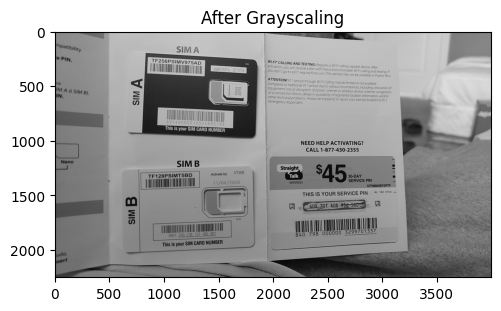

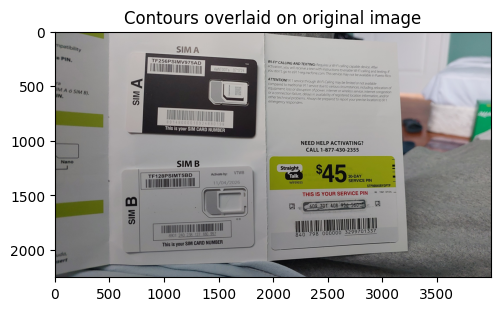

Number of Contours found = 5333


In [6]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
imshow('After Grayscaling', gray)

# Finding Contours
contours, hierarchy = cv2.findContours(gray, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
#cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))

# **NOTE: For findContours to work, the background has to be black and foreground (i.e. the text or objects)** 

#### Otherwise you'll need to invert the image by using **cv2..bitwise_not(input_image)**

#### **We can use Canny Edges instead of Thresholding**

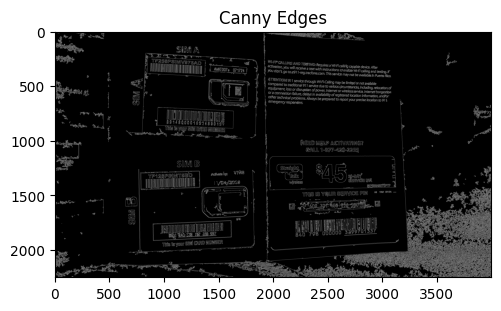

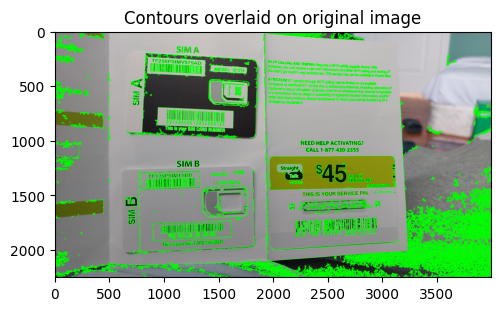

Number of Contours found = 16325


In [7]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Canny Edges
edged = cv2.Canny(gray, 30, 200)
imshow('Canny Edges', edged)

# Finding Contours
contours, hierarchy = cv2.findContours(edged, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))


## **Remember these Countouring Steps**

1. Grayscale
2. Threshold or Canny Edge Detection to Binarize image

**Note:** Blurring before Step 2 is recommended to remove noisy contours

# **Retreival Modes** 

Official Doc - https://docs.opencv.org/master/d9/d8b/tutorial_py_contours_hierarchy.html

**Hierachry**

This array stores 4 values for each contour:
- First term is the index of the Next contour
- Second term is the index of the Previous contour
- Third term is the index of the parent contour
- Forth term is the index of the child contour

### **RETR_LIST**
Retrieves all the contours, but doesn't create any parent-child relationship. Parents and kids are equal under this rule, and they are just contours. ie they all belongs to same hierarchy level.

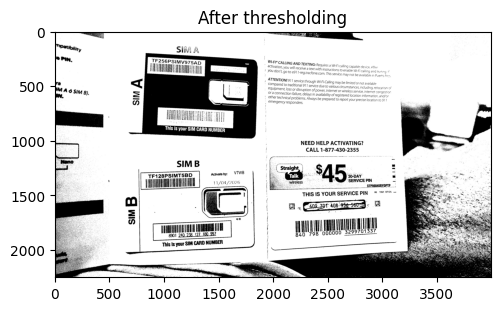

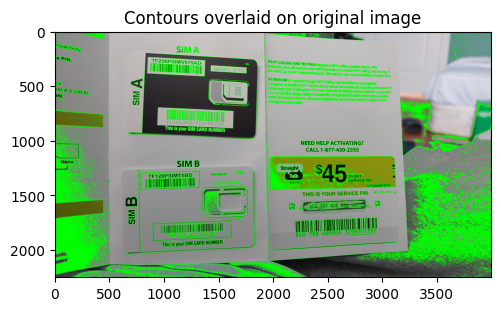

Number of Contours found = 48169
[[[    1    -1    -1    -1]
  [    2     0    -1    -1]
  [    3     1    -1    -1]
  ...
  [48167 48165    -1    -1]
  [48168 48166    -1    -1]
  [   -1 48167    -1    -1]]]


In [8]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))
print(hierarchy)

### **RETR_EXTERNAL**

Returns only extreme outer flags. All child contours are left behind.

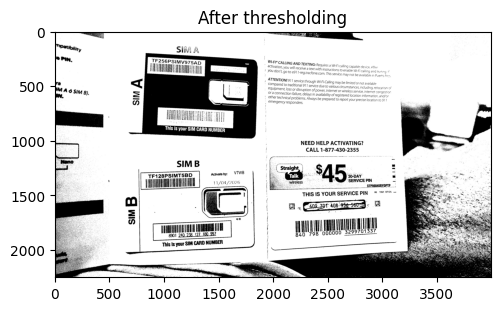

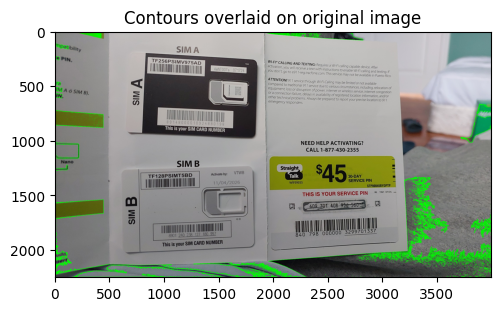

Number of Contours found = 6046
[[[   1   -1   -1   -1]
  [   2    0   -1   -1]
  [   3    1   -1   -1]
  ...
  [6044 6042   -1   -1]
  [6045 6043   -1   -1]
  [  -1 6044   -1   -1]]]


In [9]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image, size = 10)

print("Number of Contours found = " + str(len(contours)))
print(hierarchy)

### **RETR_CCOMP**

Retrieves all the contours and arranges them to a 2-level hierarchy. ie external contours of the object (ie its boundary) are placed in hierarchy-1. And the contours of holes inside object (if any) is placed in hierarchy-2. If any object inside it, its contour is placed again in hierarchy-1 only. And its hole in hierarchy-2 and so on.

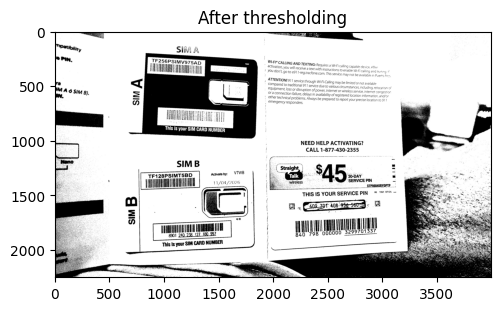

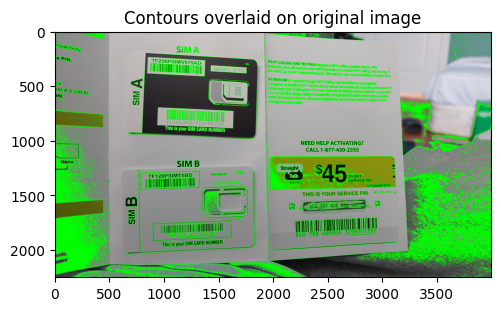

Number of Contours found = 48169
[[[    1    -1    -1    -1]
  [    2     0    -1    -1]
  [    3     1    -1    -1]
  ...
  [48167 48165    -1 13193]
  [48168 48166    -1 13193]
  [   -1 48167    -1 13193]]]


In [10]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))
print(hierarchy)

### **RETR_TREE**
It retrieves all the contours and creates a full family hierarchy list.

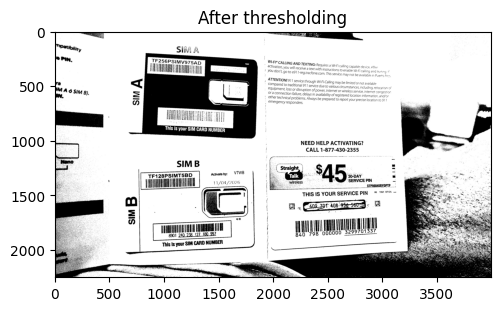

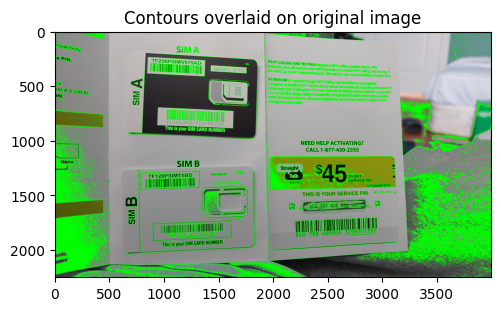

Number of Contours found = 48169
[[[    1    -1    -1    -1]
  [    2     0    -1    -1]
  [    3     1    -1    -1]
  ...
  [48167 48165    -1  8533]
  [48168 48166    -1  8533]
  [   -1 48167    -1  8533]]]


In [11]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))
print(hierarchy)

## **Contouring Modes**

#### **CHAIN_APPROX_NONE**

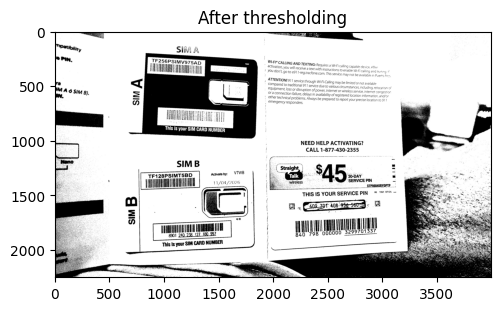

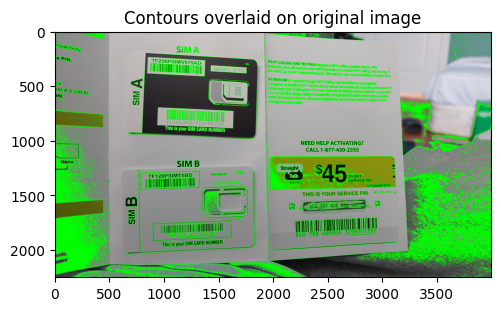

Number of Contours found = 48169
1
4
2
2
2
1
1
1
2
2
1
1
1
7
2
3
4
4
3
2
3
3
1
3
1
4
4
3
2
4
2
2
4
4
2
5
5
4
2
11
4
4
6
26
16
2
2
1
1
3
1
7
7
1
1
6
1
9
2
22
6
16
12
9
2
4
2
2
8
21
12
7
3
2
16
1
1
16
2
16
1
26
12
2
1
65
4
3
2
13
32
15
1
17
37
1
14
16
3
3
2
1
2
10
20
2
3
5
2
8
1
1
2
1
4
4
4
2
2
7
4
2
13
5
10
5
1
14
3
1
1
12
6
4
6
7
7
5
2
15
1
2
1
12
1
1
2
1
1
1
1
1
2
1
1
15
3
28
6
1
12
5
5
3
13
3
1
1
2
1
8
5
1
1
4
4
1
2
1
1
1
2
12
1
10
8
17
16
4
5
1
1
1
5
1
5
17
1
6
1
1
1
2
1
2
2
1
1
3
5
1
8
2
1
4
2
1
1
8
12
1
7
3
39
4
1
1
10
1
4
8
1
3
3
4
1
21
2
13
8
6
3
2
1
1
8
1
1
1
2
2
1
1
1
1
1
4
1
1
1
2
1
3
1
16
3
1
1
3
1
5
6
2
4
5
1
1
4
3
1
3
10
2
1
3
6
3
1
2
1
1
4
22
2
8
3
1
2
1
1
1
1
1
4
14
1
2
1
2
61
9
7
2
24
15
1
1
1
10
9
14
1
2
2
5
1
4
1
5
1
5
1
4
4
6
61
4
25
8
2
1
2
2
1
1
5
1
3
1
9
1
6
1
1
1
4
1
34
6
23
7
1
5
2
1
1
1
2
1
7
14
1
8
2
1
1
1
10
12
2
1
1
8
9
2
1
526
4
4
4
11
6
4
6
7
4
7
4
4
4
4
6
4
10
8
4
12
6
4
6
19
4
4
4
4
4
7
6
6
4
13
37
2
1
4
10
8
4
69
3
133
4
3
4
4
4
4
9
8
4
7
4
4
4
1
1
4
1


In [12]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))
for c in contours:
  print(len(c))


#### **CHAIN_APPROX_SIMPLE**

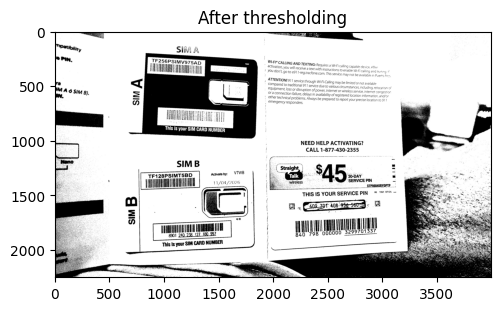

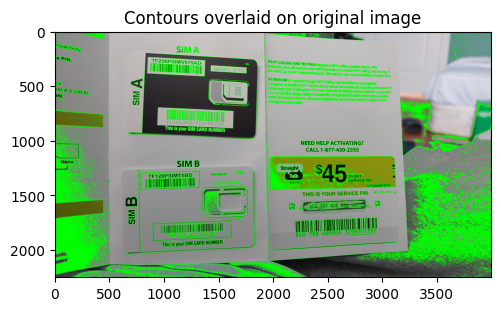

Number of Contours found = 48169
1
2
2
2
2
1
1
1
2
2
1
1
1
5
2
3
4
4
3
2
3
3
1
3
1
4
4
3
2
3
2
2
4
4
2
4
4
2
2
8
4
4
6
12
11
2
2
1
1
3
1
5
5
1
1
5
1
7
2
16
4
12
6
7
2
4
2
2
2
16
9
4
3
2
11
1
1
13
2
13
1
17
9
2
1
37
4
3
2
10
23
12
1
13
21
1
12
12
3
3
2
1
2
6
8
2
3
4
2
6
1
1
2
1
2
3
2
2
2
4
4
2
6
4
6
4
1
2
3
1
1
10
2
2
4
6
6
4
2
6
1
2
1
8
1
1
2
1
1
1
1
1
2
1
1
12
3
16
6
1
8
4
4
3
7
3
1
1
2
1
4
4
1
1
2
2
1
2
1
1
1
2
6
1
9
4
10
11
4
4
1
1
1
4
1
4
12
1
2
1
1
1
2
1
2
2
1
1
3
4
1
6
2
1
4
2
1
1
6
7
1
7
3
28
4
1
1
6
1
4
6
1
3
3
3
1
10
2
9
8
6
3
2
1
1
7
1
1
1
2
2
1
1
1
1
1
4
1
1
1
2
1
3
1
12
3
1
1
3
1
4
4
2
4
4
1
1
4
3
1
3
7
2
1
3
6
3
1
2
1
1
3
16
2
4
3
1
2
1
1
1
1
1
2
10
1
2
1
2
48
7
6
2
16
13
1
1
1
4
5
8
1
2
2
4
1
4
1
4
1
4
1
2
3
4
42
4
17
7
2
1
2
2
1
1
4
1
3
1
9
1
5
1
1
1
4
1
26
6
17
6
1
4
2
1
1
1
2
1
4
10
1
5
2
1
1
1
10
5
2
1
1
6
6
2
1
346
4
4
4
9
6
4
6
6
4
6
4
4
4
4
6
4
6
6
4
9
6
4
6
15
4
4
4
4
4
6
6
6
4
10
28
2
1
4
7
6
4
46
3
91
2
3
4
4
4
4
7
8
4
6
4
4
4
1
1
4
1
1
8
7
2
5
8
1
3
1
1
10
1
1


In [13]:
image = cv2.imread('../files/images/america12.jpg')

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow('After thresholding', th2)

# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(th2, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image, contours, -1, (0,255,0), thickness = 2)
imshow('Contours overlaid on original image', image)

print("Number of Contours found = " + str(len(contours)))
for c in contours:
  print(len(c))